# 动态行为层测试 - 2026-04-21

测试动态行为层（3.1.2Dynamic_Stats）所有新函数：
- M9/V9: 通勤时间指标 + TAZ地图 + 饼图
- M10/V10: 交通方式统计 + 饼图
- V11: OD流线图（transbigdata + Mapbox）
- V12: 社区发现（igraph Louvain）
- V13: 基于OD流的标准差椭圆

In [1]:
import sys
from pathlib import Path

project_root = Path(r"E:\00_Commute_Scenario_Research")
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import geopandas as gpd

from src import (
    OD_FEATURE_CSV, SHP_PATH, get_result_path, logger,
)
from src.data_prep import load_fence

print("模块加载完成")

模块加载完成


In [2]:
# 加载数据
fence = load_fence(SHP_PATH)
print(f"TAZ数: {len(fence)}")

# 加载完整OD数据（507.9 MB，含时间和交通方式）
print("加载完整OD数据...")
df_od_full = pd.read_csv(OD_FEATURE_CSV, encoding='utf-8-sig')
df_od_full = df_od_full.rename(columns={'Htaz': 'o', 'Jtaz': 'd'})
print(f"OD数据行数: {len(df_od_full)}")
print(f"列名: {df_od_full.columns.tolist()}")
print(f"总人数: {df_od_full['人数'].sum():.0f}")

2026-04-21 17:17:06,111 - INFO - 地理围栏原始行数: 4817, unique taz: 2427, CRS=EPSG:4326
2026-04-21 17:17:07,938 - INFO - dissolve后行数: 2427


TAZ数: 2427
加载完整OD数据...
OD数据行数: 1861301
列名: ['行编号', '起点网格ID', '终点网格ID', 'o', 'd', '日期', '人数', '平均通勤时间(s)', '驾车比例', '地铁比例', '公交比例', '骑行比例', '步行比例', 'housing_point', 'job_point', 'housing_district', 'job_district']
总人数: 2212508


In [3]:
MAPBOX_TOKEN = os.getenv("MAPBOX_TOKEN")\nif not MAPBOX_TOKEN:\n    raise RuntimeError("MAPBOX_TOKEN is not set")
BOUNDS = [112.68, 27.8, 113.3, 28.6]
OUTPUT_SECTION = '3.Situation_Diagnosis/3.1Holistic_Diagnosis/3.1.2Dynamic_Stats'

## M9/V9: 通勤时间指标

In [4]:
from src.metrics_eval import compute_time_indicators
from src.visualization import create_pie_chart

gdf_time, time_stats = compute_time_indicators(df_od_full, fence)
print(f"TAZ级时间数据: {len(gdf_time)} 行")
print(f"全局平均通勤时间: {time_stats['全局平均时间_min']:.2f} 分钟")
print("时长分段统计:")
for k, v in time_stats.items():
    if k != '全局平均时间_min':
        print(f"  {k}: {v} 人")

# 保存TAZ级时间CSV
out_csv = get_result_path(OUTPUT_SECTION, 'star_动态行为指标_时间.csv')
gdf_time[['taz', '平均通勤时间_min']].to_csv(out_csv, index=False, encoding='utf-8-sig')

# 时长区间饼图
pie_data = {k: v for k, v in time_stats.items() if k != '全局平均时间_min'}
out_pie = get_result_path(OUTPUT_SECTION, 'star_通勤时长区间占比_饼图.png')
create_pie_chart(pie_data, out_pie, title='通勤时长区间占比')
print(f"饼图已保存: {out_pie}")

2026-04-21 17:17:21,803 - INFO - compute_time_indicators: TAZ数=2427, 全局平均时间=31.84分钟


TAZ级时间数据: 2427 行
全局平均通勤时间: 31.84 分钟
时长分段统计:
  <15分钟: 124525 人
  15-30分钟: 562999 人
  30-45分钟: 259336 人
  45-60分钟: 131179 人
  >60分钟: 97418 人


2026-04-21 17:17:22,279 - INFO - 饼图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_通勤时长区间占比_饼图.png


饼图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_通勤时长区间占比_饼图.png


2026-04-21 17:17:22,286 - INFO - 开始执行: create_choropleth_map
2026-04-21 17:17:28,011 - INFO - 地图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_平均通勤时间分布图_TAZ.png
2026-04-21 17:17:28,016 - INFO - 统计信息已保存: E:\00_Commute_Scenario_Research\results\create_choropleth_map_stats.csv
2026-04-21 17:17:28,019 - INFO - 完成: create_choropleth_map, 耗时: 5.73秒


TAZ时间地图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_平均通勤时间分布图_TAZ.png


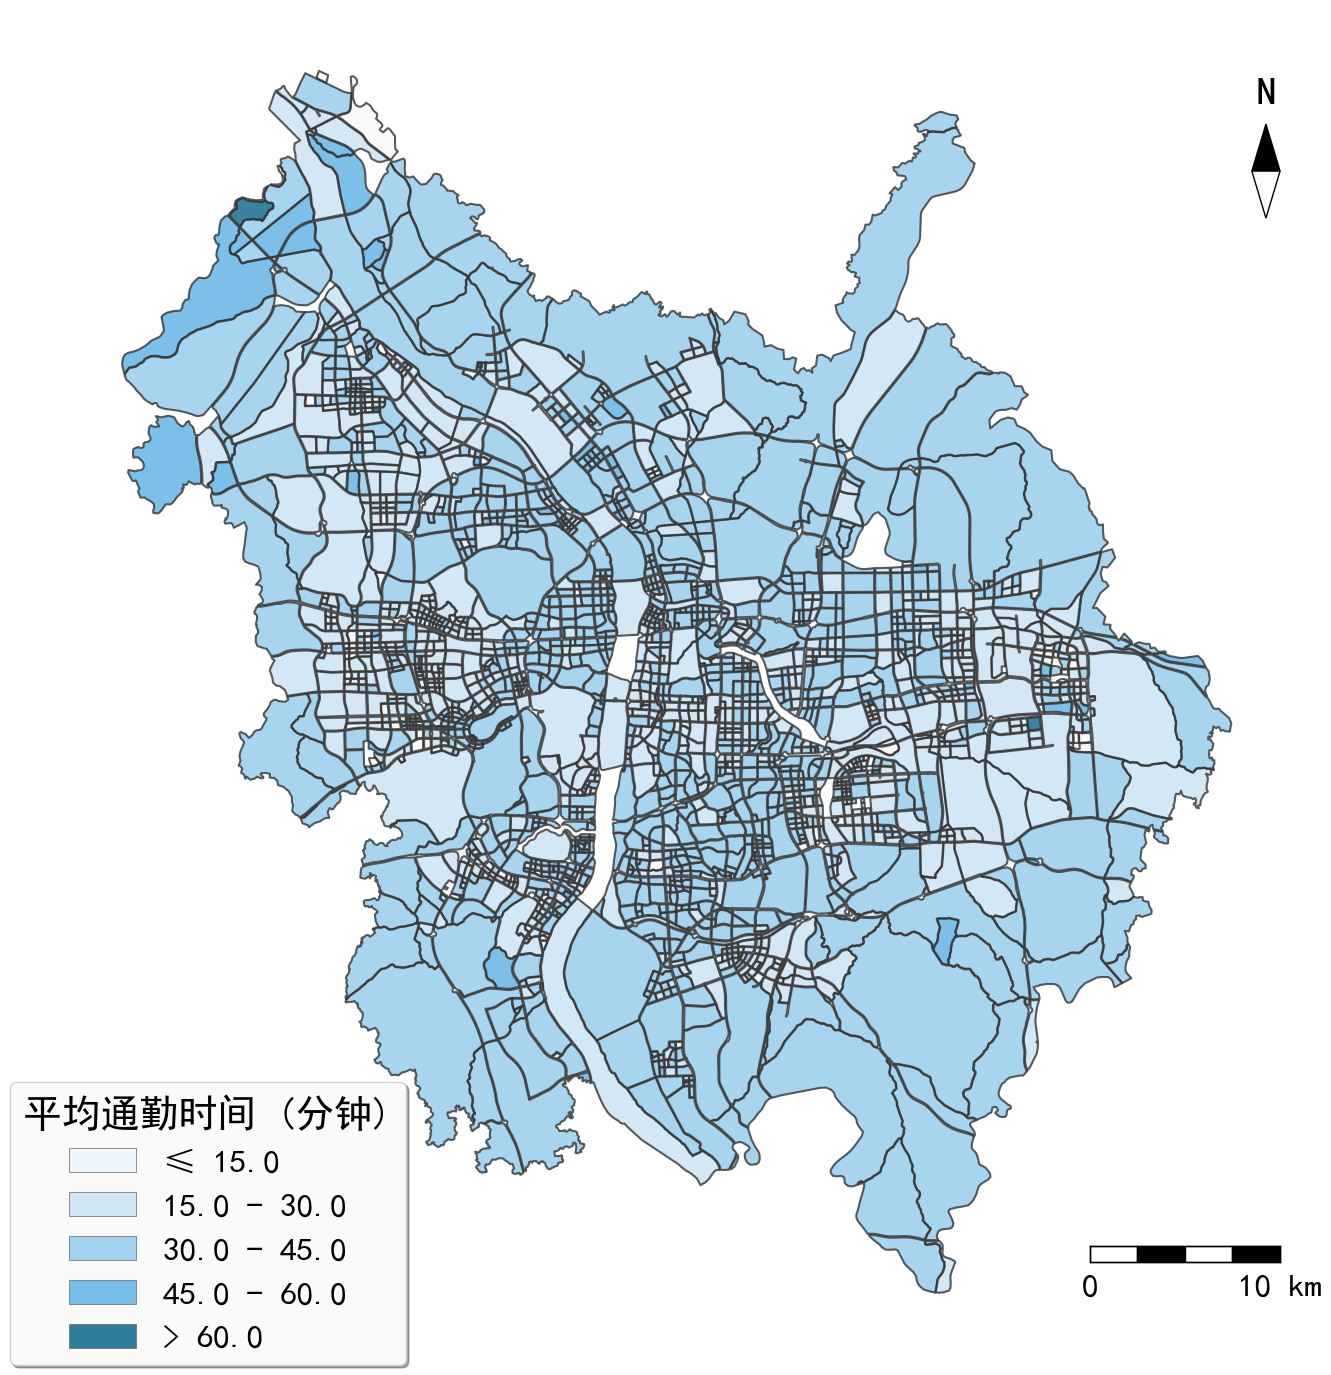

In [5]:
# TAZ级时间地图（需要先在config中添加avg_time配色方案）
from src.visualization import create_choropleth_map
from src.config import COLOR_SCHEMES

# 临时添加avg_time配色方案（如果不存在）
if 'avg_time' not in COLOR_SCHEMES:
    COLOR_SCHEMES['avg_time'] = {
        'name': '平均通勤时间',
        'colors': ['#EFF7FC', '#D1E7F5', '#A3D2EF', '#75BDE9', '#2E7D9A'],
        'bins': [0, 15, 30, 45, 60, 120],
        'unit': '分钟',
        'decimals': 1
    }

out_map = get_result_path(OUTPUT_SECTION, 'star_平均通勤时间分布图_TAZ.png')
create_choropleth_map(gdf_time, fence, '平均通勤时间_min', 'avg_time', out_map)
print(f"TAZ时间地图已保存: {out_map}")

## M10/V10: 交通方式统计

In [6]:
from src.metrics_eval import compute_transport_mode_stats

mode_stats = compute_transport_mode_stats(df_od_full)
print("交通方式占比:")
for mode, ratio in mode_stats.items():
    print(f"  {mode}: {ratio:.2%}")

# 保存CSV
out_csv = get_result_path(OUTPUT_SECTION, 'star_动态行为指标_交通方式.csv')
pd.DataFrame([mode_stats]).to_csv(out_csv, index=False, encoding='utf-8-sig')

# 饼图
out_pie = get_result_path(OUTPUT_SECTION, 'star_交通方式占比_饼图.png')
create_pie_chart(mode_stats, out_pie, title='交通方式占比')
print(f"交通方式饼图已保存: {out_pie}")

2026-04-21 17:17:28,827 - INFO - compute_transport_mode_stats: 驾车=16.30%, 地铁=19.71%, 公交=32.19%, 骑行=17.03%, 步行=11.05%


交通方式占比:
  驾车: 16.30%
  地铁: 19.71%
  公交: 32.19%
  骑行: 17.03%
  步行: 11.05%


2026-04-21 17:17:29,186 - INFO - 饼图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_交通方式占比_饼图.png


交通方式饼图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_交通方式占比_饼图.png


## V13: 基于OD流的标准差椭圆

In [7]:
from src.geo_excu import plot_std_ellipse_flow

out_fig = get_result_path(OUTPUT_SECTION, 'star_标准差椭圆_通勤流.png')
result = plot_std_ellipse_flow(df_od_full, fence, out_fig)
print(f"通勤流标准差椭圆已保存: {out_fig}")
print(f"  长半轴: {result['semi_major']:.2f} 米")
print(f"  短半轴: {result['semi_minor']:.2f} 米")
print(f"  方向角: {result['angle_deg']:.2f}°")

2026-04-21 17:17:33,531 - INFO - 通勤流标准差椭圆图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_标准差椭圆_通勤流.png


通勤流标准差椭圆已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_标准差椭圆_通勤流.png
  长半轴: 16346.74 米
  短半轴: 12367.30 米
  方向角: 145.12°


## V11: OD流线图（transbigdata + Mapbox）

In [9]:
from src.visualization import create_od_flowmap_tbd

out_html = get_result_path(OUTPUT_SECTION, 'star_OD流线图_实际格局.html')
create_od_flowmap_tbd(
    df_od=df_od_full,
    fence=fence,
    output_path=out_html,
    mapbox_token=MAPBOX_TOKEN,
    bounds=BOUNDS,
    top_n=500,
)
print(f"OD流线图已保存: {out_html}")

2026-04-21 17:23:55,260 - INFO - OD流线图HTML已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_OD流线图_实际格局.html
2026-04-21 17:23:55,410 - WARNING - HTML转PNG失败: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.


OD流线图已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_OD流线图_实际格局.html


## V12: 社区发现（igraph Louvain）

In [10]:
from src.geo_excu import community_detection_tbd

out_html = get_result_path(OUTPUT_SECTION, 'star_社区发现结果.html')
result = community_detection_tbd(
    df_od=df_od_full,
    fence=fence,
    output_path=out_html,
    mapbox_token=MAPBOX_TOKEN,
    bounds=BOUNDS,
)
print(f"社区发现完成:")
print(f"  模块度: {result['modularity']:.4f}")
print(f"  社区数: {result['n_communities']}")
print(f"  最大社区TAZ数: {result['community_sizes'][0]}")

2026-04-21 17:32:50,629 - INFO - 社区发现模块度报告已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_社区发现结果_模块度报告.txt
2026-04-21 17:32:58,997 - INFO - 社区发现HTML已保存: E:\00_Commute_Scenario_Research\results\3.Situation_Diagnosis\3.1Holistic_Diagnosis\3.1.2Dynamic_Stats\star_社区发现结果.html
2026-04-21 17:32:59,032 - WARNING - HTML转PNG失败: It looks like you are using Playwright Sync API inside the asyncio loop.
Please use the Async API instead.


社区发现完成:
  模块度: 0.4850
  社区数: 8
  最大社区TAZ数: 503


## 汇总统计输出

In [ ]:
# 生成动态行为指标汇总CSV
summary = {
    '全局平均通勤时间_min': time_stats['全局平均时间_min'],
    '通勤时长<15min占比': pie_data.get('<15分钟', 0) / sum(pie_data.values()),
    '通勤时长15-30min占比': pie_data.get('15-30分钟', 0) / sum(pie_data.values()),
    '通勤时长30-45min占比': pie_data.get('30-45分钟', 0) / sum(pie_data.values()),
    '通勤时长45-60min占比': pie_data.get('45-60分钟', 0) / sum(pie_data.values()),
    '通勤时长>60min占比': pie_data.get('>60分钟', 0) / sum(pie_data.values()),
}
summary.update({f'交通方式_{k}': v for k, v in mode_stats.items()})

out_summary = get_result_path(OUTPUT_SECTION, 'star_动态行为指标汇总.csv')
pd.DataFrame([summary]).to_csv(out_summary, index=False, encoding='utf-8-sig')
print(f"汇总CSV已保存: {out_summary}")

print("\n=" * 40)
print("动态行为层测试完成！")
print("=" * 40)